In [1]:
!pip install -q opencv-python

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from tensorflow.keras.models import load_model

In [3]:
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR="/content/drive/MyDrive/computervisionproject"

MODEL_PATH=os.path.join(
    PROJECT_DIR,
    "models",
    "best_model.keras"
)

TEST_DIR=os.path.join(
    PROJECT_DIR,
    "dataset",
    "processed_dataset",
    "test"
)

SAVE_DIR=os.path.join(
    PROJECT_DIR,
    "reports",
    "gradcam"
)

os.makedirs(SAVE_DIR,exist_ok=True)

In [5]:
model=load_model(MODEL_PATH)

print("Model Loaded")

model.summary()

Model Loaded


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,053,422 (26.91 MB)

 Trainable params: 1,500,003 (5.72 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,000,008 (11.44 MB)

In [6]:
CLASS="COVID"

folder=os.path.join(TEST_DIR,CLASS)

image_name=random.choice(os.listdir(folder))

IMAGE_PATH=os.path.join(folder,image_name)

print(IMAGE_PATH)

/content/drive/MyDrive/computervisionproject/dataset/processed_dataset/test/COVID/COVID-1771.png


In [7]:
IMG_SIZE=224

img=cv2.imread(IMAGE_PATH)

img=cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

original=img.copy()

img=cv2.resize(
    img,
    (IMG_SIZE,IMG_SIZE)
)

input_image=np.expand_dims(
    img.astype(np.float32),
    axis=0
)

In [11]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        base_model.output,
        model.output
    ]
)

In [13]:
last_conv_layer = base_model.get_layer("top_activation")

print(
    "Grad-CAM layer:",
    last_conv_layer.name
)

print(
    "Output shape:",
    last_conv_layer.output.shape
)

Grad-CAM layer: top_activation
Output shape: (None, 7, 7, 1280)


In [15]:
efficientnet = model.get_layer("efficientnetb0")
gap = model.get_layer("global_average_pooling2d")
dropout = model.get_layer("dropout")
dense = model.get_layer("dense")

In [16]:
grad_model = tf.keras.models.Model(
    inputs=efficientnet.input,
    outputs=[
        efficientnet.output
    ]
)

In [17]:
preprocessing_layer = model.get_layer("sequential")

processed_image = preprocessing_layer(
    input_image,
    training=False
)

print(processed_image.shape)

(1, 224, 224, 3)


In [18]:
features = efficientnet(
    processed_image,
    training=False
)

print(features.shape)

(1, 7, 7, 1280)


In [19]:
with tf.GradientTape() as tape:

    processed_image = preprocessing_layer(
        input_image,
        training=False
    )

    features = efficientnet(
        processed_image,
        training=False
    )

    pooled = gap(features)

    dropped = dropout(
        pooled,
        training=False
    )

    predictions = dense(dropped)

    class_score = predictions[:, predicted_index]

gradients = tape.gradient(
    class_score,
    features
)

In [20]:
pooled_gradients = tf.reduce_mean(
    gradients,
    axis=(1, 2)
)

In [21]:
features = features[0]

pooled_gradients = pooled_gradients[0]

In [22]:
heatmap = tf.reduce_sum(
    features * pooled_gradients,
    axis=-1
)

In [23]:
heatmap = tf.maximum(
    heatmap,
    0
)

In [24]:
heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-8
)

In [25]:
heatmap = heatmap.numpy()

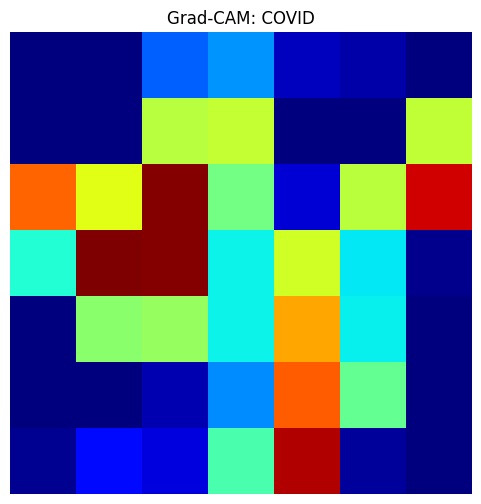

In [26]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title(
    f"Grad-CAM: {predicted_class}"
)

plt.axis("off")

plt.show()

In [27]:
heatmap = cv2.resize(
    heatmap,
    (
        original.shape[1],
        original.shape[0]
    )
)

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

In [28]:
overlay = cv2.addWeighted(
    original,
    0.65,
    heatmap,
    0.35,
    0
)

In [31]:
# Resize Grad-CAM heatmap to original image size

heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)
print("Heatmap resized shape:", heatmap_resized.shape)

Heatmap resized shape: (224, 224, 3)


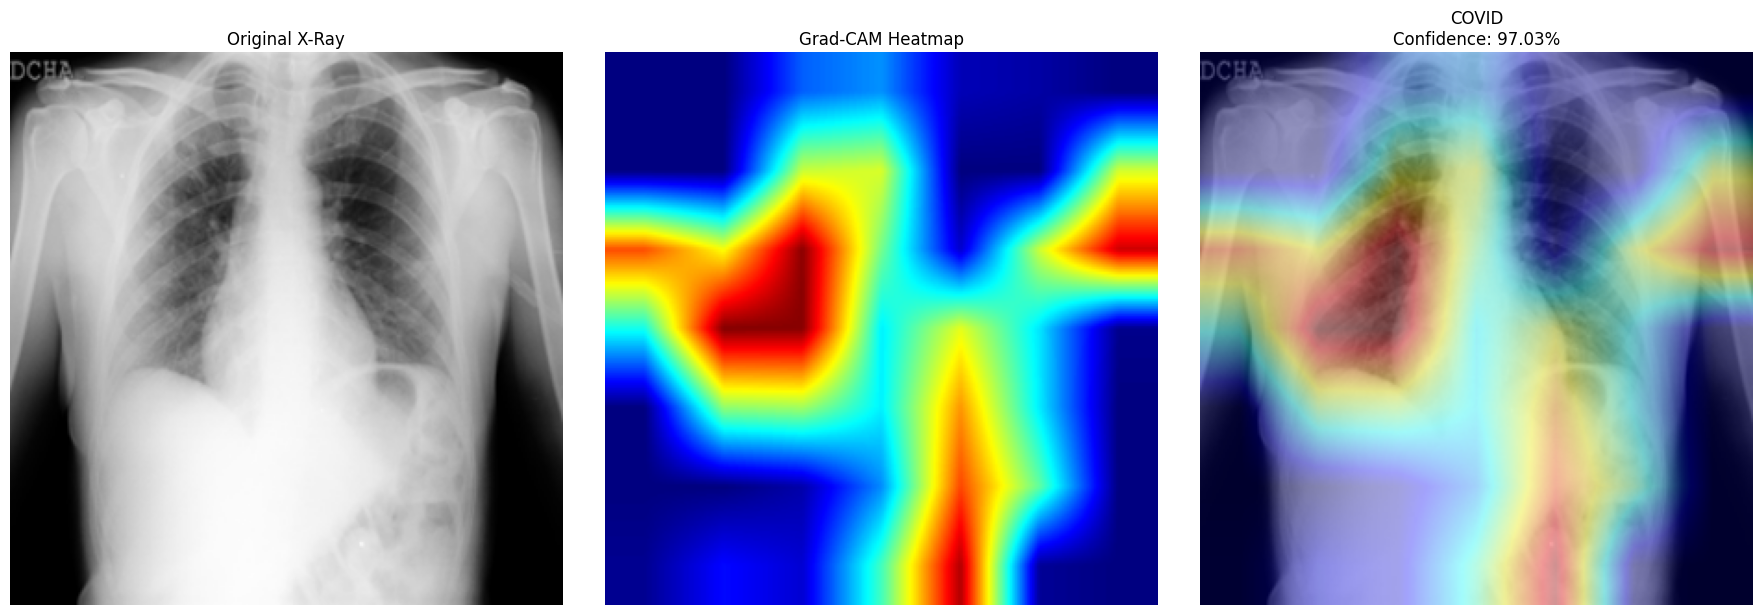

In [32]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(original)

plt.title("Original X-Ray")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(heatmap_resized, cmap="jet")

plt.title("Grad-CAM Heatmap")

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(overlay)

plt.title(
    f"{predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
save_path = os.path.join(
    SAVE_DIR,
    f"{predicted_class}_gradcam.png"
)

cv2.imwrite(
    save_path,
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)

print("Saved to")

print(save_path)